In [ ]:
!pip install transformers datasets accelerate evaluate gradio -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 7.9 MB/s eta 0:00:00


In [ ]:
from datasets import load_dataset
from transformers import (
    BertTokenizer,
    BertForSequenceClassification,
    TrainingArguments,
    Trainer
)

from sklearn.metrics import accuracy_score, f1_score
import evaluate
import numpy as np
import torch

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(device)

cuda


In [ ]:
from datasets import load_dataset

# Fix: Specify the format 'csv' and provide the file path in data_files
dataset = load_dataset("csv", data_files={"train": "/content/test.csv.zip"})

Generating train split: 0 examples [00:00, ? examples/s]

In [ ]:
dataset = dataset.rename_column("Class Index", "label")

In [ ]:
print(dataset["train"][0])

{'Class Index': 3, 'Title': 'Fears for T N pension after talks', 'Description': "Unions representing workers at Turner   Newall say they are 'disappointed' after talks with stricken parent firm Federal Mogul."}


In [ ]:
def fix_labels(example):

    example["label"] = example["Class Index"] - 1

    return example

dataset = dataset.map(fix_labels)

Map:   0%|          | 0/7600 [00:00<?, ? examples/s]

In [ ]:
print(dataset["train"][0]["label"])

2


In [ ]:
def combine_text(example):

    example["text"] = example["Title"] + " " + example["Description"]

    return example

dataset = dataset.map(combine_text)

Map:   0%|          | 0/7600 [00:00<?, ? examples/s]

In [ ]:
from transformers import BertTokenizer

tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [ ]:
def tokenize_function(example):

    return tokenizer(
        example["text"],
        padding="max_length",
        truncation=True,
        max_length=128
    )

tokenized_dataset = dataset.map(tokenize_function, batched=True)

Map:   0%|          | 0/7600 [00:00<?, ? examples/s]

In [ ]:
tokenized_dataset = tokenized_dataset.remove_columns(
    ["Title", "Description", "text"]
)

In [ ]:
tokenized_dataset.set_format("torch")

In [ ]:
from transformers import BertForSequenceClassification

model = BertForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=4
)

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
print(tokenized_dataset["train"][0]["label"])
print(tokenized_dataset["train"][100]["label"])

tensor(2)
tensor(1)


In [ ]:
print(set(dataset["train"]["label"]))

{0, 1, 2, 3}


In [ ]:
from transformers import TrainingArguments

training_args = TrainingArguments(

    output_dir="./results",

    eval_strategy="epoch",

    save_strategy="epoch",

    learning_rate=2e-5,

    per_device_train_batch_size=8,

    per_device_eval_batch_size=8,

    num_train_epochs=2,

    weight_decay=0.01,

    logging_dir="./logs",

    logging_steps=100
)

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [ ]:
from sklearn.metrics import accuracy_score, f1_score
import numpy as np

def compute_metrics(eval_pred):

    logits, labels = eval_pred

    predictions = np.argmax(logits, axis=-1)

    accuracy = accuracy_score(labels, predictions)

    f1 = f1_score(labels, predictions, average="weighted")

    return {
        "accuracy": accuracy,
        "f1": f1
    }

In [ ]:
from transformers import Trainer

# Split the tokenized_dataset into training and evaluation sets
splits = tokenized_dataset["train"].train_test_split(test_size=0.2, seed=42)
train_dataset = splits["train"]
eval_dataset = splits["test"]

trainer = Trainer(

    model=model,

    args=training_args,

    train_dataset=train_dataset,

    eval_dataset=eval_dataset,

    compute_metrics=compute_metrics
)

In [ ]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.302005,0.366794,0.895395,0.895533
2,0.254240,0.333870,0.919079,0.919199


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=1520, training_loss=0.3041415223949834, metrics={'train_runtime': 321.2744, 'train_samples_per_second': 37.849, 'train_steps_per_second': 4.731, 'total_flos': 799871971491840.0, 'train_loss': 0.3041415223949834, 'epoch': 2.0})

In [ ]:
results = trainer.evaluate()

print(results)

{'eval_loss': 0.33386966586112976, 'eval_accuracy': 0.9190789473684211, 'eval_f1': 0.9191994124019119, 'eval_runtime': 10.5792, 'eval_samples_per_second': 143.679, 'eval_steps_per_second': 17.96, 'epoch': 2.0}


In [ ]:
model.save_pretrained("news_model")

tokenizer.save_pretrained("news_model")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('news_model/tokenizer_config.json', 'news_model/tokenizer.json')

In [ ]:
def predict_news(text):

    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=128
    )

    inputs = {k: v.to(device) for k, v in inputs.items()}

    outputs = model(**inputs)

    prediction = outputs.logits.argmax().item()

    return label_names[prediction]

In [ ]:
# Define label_names to map numerical predictions to category names
# Assuming these are the categories based on typical news datasets and 4 labels.
label_names = ["World", "Sports", "Business", "Sci/Tech"]

sample = "Apple launches new AI-powered iPhone"

result = predict_news(sample)

print("Prediction:", result)

Prediction: Sci/Tech


In [ ]:
import gradio as gr

def classify(text):
    return predict_news(text)

interface = gr.Interface(
    fn=classify,

    inputs="text",

    outputs="text",

    title="News Topic Classifier",

    description="Enter a news headline"
)

interface.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://73f00e01f43ede4a56.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


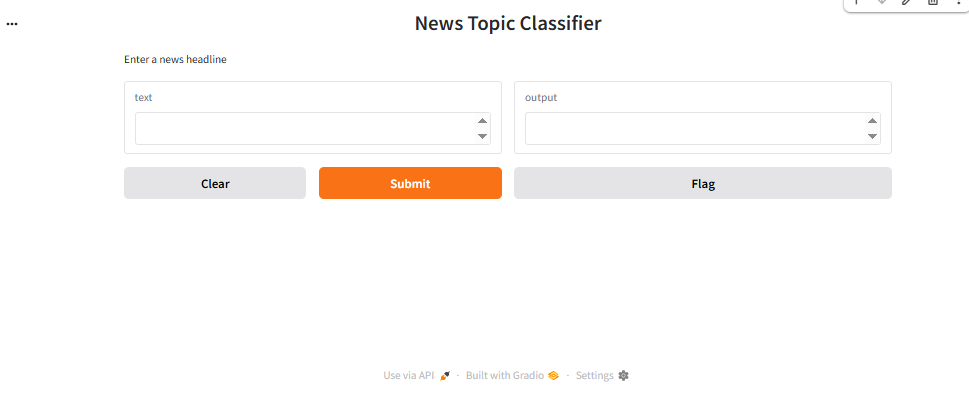